In [1]:
# ============================================================
# CELL 1: SETUP & IMPORTS
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Input,
                                      Conv1D, MaxPooling1D, Bidirectional)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


Mounted at /content/drive
TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# ============================================================
# CELL 2: ΦΟΡΤΩΣΗ PV DATASET
# ============================================================
PV_PATH = '/content/drive/MyDrive/Final_RUn/241-Site_DKA_Totals-PV.csv'

df_raw = pd.read_csv(PV_PATH, engine='python', on_bad_lines='skip')
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw = df_raw.dropna(subset=['timestamp']).set_index('timestamp').sort_index()

print(f"Raw shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min()}  ->  {df_raw.index.max()}")
print(f"\nΣτήλες: {list(df_raw.columns)}")


Raw shape: (182295, 12)
Date range: 2023-12-07 13:15:00  ->  2025-09-04 12:15:00

Στήλες: ['Reactive_Power', 'Active_Power', 'Apparent_Power', 'Wind_Speed', 'Weather_Temperature_Celsius', 'Weather_Relative_Humidity', 'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation', 'Wind_Direction', 'Weather_Daily_Rainfall', 'Radiation_Global_Tilted', 'Radiation_Diffuse_Tilted']


In [3]:
# ============================================================
# CELL 3: CLEANING
# ============================================================
df = pd.DataFrame(index=df_raw.index)
df['PV_Power'] = df_raw['Active_Power']

weather_cols = [
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation'
]
for col in weather_cols:
    df[col] = df_raw[col]

# --- Cleaning ---
df.loc[(df['PV_Power'] < 0) & (df['PV_Power'] > -10), 'PV_Power'] = 0
df.loc[df['PV_Power'] < -10, 'PV_Power'] = np.nan
df['Weather_Relative_Humidity'] = df['Weather_Relative_Humidity'].clip(0, 100)
for rad in ['Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']:
    df.loc[df[rad] < 0, rad] = 0

# Outage detection: GHI > 100 αλλά PV < 5 kW => αισθητήρας/βλάβη
ghi_filled = df['Global_Horizontal_Radiation'].fillna(0)
outage_mask = (ghi_filled > 100) & (df['PV_Power'] < 5)
df.loc[outage_mask, 'PV_Power'] = np.nan
print(f"Outages removed: {outage_mask.sum():,}")

# Filter
df = df.loc['2024-03-01':].copy()
print(f"Shape μετά filter: {df.shape}")
print(f"NaNs ανά στήλη:\n{df.isna().sum()}")


Outages removed: 156
Shape μετά filter: (159086, 5)
NaNs ανά στήλη:
PV_Power                        17044
Weather_Temperature_Celsius     36251
Weather_Relative_Humidity       36247
Global_Horizontal_Radiation     36232
Diffuse_Horizontal_Radiation    36232
dtype: int64


In [4]:
# ============================================================
# CELL 4: KNN IMPUTATION + CYCLICAL FEATURES
# ============================================================
from sklearn.preprocessing import StandardScaler

# Drop rows με NaN στο target
before = len(df)
df = df.dropna(subset=['PV_Power'])
print(f"Drop NaN target: {before - len(df):,}")

# KNN Imputation για weather
imp_cols = ['Weather_Temperature_Celsius', 'Weather_Relative_Humidity',
            'Global_Horizontal_Radiation', 'Diffuse_Horizontal_Radiation']
z = StandardScaler()
arr = z.fit_transform(df[imp_cols])
arr = KNNImputer(n_neighbors=5, weights='distance').fit_transform(arr)
df[imp_cols] = z.inverse_transform(arr)

# Cyclical encoding
df['hour_sin']  = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos']  = np.cos(2*np.pi*df.index.hour/24)
df['month_sin'] = np.sin(2*np.pi*df.index.month/12)
df['month_cos'] = np.cos(2*np.pi*df.index.month/12)

print(f"\nFinal shape: {df.shape}")
print(f"NaNs τώρα: {df.isna().sum().sum()}")
df.head(3)


Drop NaN target: 17,044

Final shape: (142042, 9)
NaNs τώρα: 0


,PV_Power,Weather_Temperature_Celsius,Weather_Relative_Humidity,Global_Horizontal_Radiation,Diffuse_Horizontal_Radiation,hour_sin,hour_cos,month_sin,month_cos
timestamp,,,,,,,,,
2024-03-01 00:00:00,0.0,27.023981,68.958588,1.115154,0.838498,0.0,1.0,1.0,6.123234e-17
2024-03-01 00:05:00,0.0,26.972717,68.860062,1.103236,0.763736,0.0,1.0,1.0,6.123234e-17
2024-03-01 00:10:00,0.0,26.921713,68.862221,1.090453,0.843003,0.0,1.0,1.0,6.123234e-17


In [5]:
# ============================================================
# CELL 5: TRAIN/TEST SPLIT + SCALING
# ============================================================
# Features (raw + cyclical, ΟΧΙ lag/rolling)
FEATURES = [
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
]
TARGET = 'PV_Power'

split = int(len(df) * 0.80)
train_df = df.iloc[:split].copy()
test_df  = df.iloc[split:].copy()

print(f"Train: {len(train_df):,}  ({train_df.index.min()} -> {train_df.index.max()})")
print(f"Test:  {len(test_df):,}  ({test_df.index.min()} -> {test_df.index.max()})")

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_X.fit_transform(train_df[FEATURES])
y_train = scaler_y.fit_transform(train_df[[TARGET]]).flatten()
X_test  = scaler_X.transform(test_df[FEATURES])
y_test  = scaler_y.transform(test_df[[TARGET]]).flatten()

# Target range για nMAE μετρικές
target_range = train_df[TARGET].max() - train_df[TARGET].min()
print(f"\nTarget range (train): {target_range:.2f} kW")


Train: 113,633  (2024-03-01 00:00:00 -> 2025-05-11 20:00:00)
Test:  28,409  (2025-05-11 20:05:00 -> 2025-09-04 12:15:00)

Target range (train): 240.19 kW


In [6]:
# ============================================================
# CELL 6: SEQUENCE CREATION HELPER
# ============================================================
def create_sequences(X, y, lookback, horizon=1):
    """
    X: (N, n_features), y: (N,)
    Επιστρέφει:
      Xs: (samples, lookback, n_features)
      ys: (samples,) αν horizon=1, αλλιώς (samples, horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i:i+lookback])
        if horizon == 1:
            ys.append(y[i+lookback])
        else:
            ys.append(y[i+lookback : i+lookback+horizon])
    return np.array(Xs), np.array(ys)


def evaluate(y_true_scaled, y_pred_scaled, scaler_y, target_range):
    """Inverse-scale και μετρικές."""
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    nmae = mae / target_range * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nMAE%': nmae,
            'y_true': y_true, 'y_pred': y_pred}


print("Helpers OK")


Helpers OK


In [7]:
# ============================================================
# CELL 7: 5-MIN SEQUENCES
# ============================================================
LOOKBACK_5MIN = 96   # 8 hours
HORIZON_5MIN  = 1

X_tr_5, y_tr_5 = create_sequences(X_train, y_train, LOOKBACK_5MIN, HORIZON_5MIN)
X_te_5, y_te_5 = create_sequences(X_test,  y_test,  LOOKBACK_5MIN, HORIZON_5MIN)

print(f"X_train sequences: {X_tr_5.shape}  y: {y_tr_5.shape}")
print(f"X_test  sequences: {X_te_5.shape}  y: {y_te_5.shape}")


X_train sequences: (113537, 96, 8)  y: (113537,)
X_test  sequences: (28313, 96, 8)  y: (28313,)


In [8]:
# ============================================================
# CELL 8: STACKED LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_lstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    LSTM(64, return_sequences=True,  activation='relu'),
    LSTM(32, return_sequences=True,  activation='relu'),
    LSTM(32, return_sequences=False, activation='relu'),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_lstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                     loss='mse', metrics=['mae'])

cb = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]
t0 = time.time()
h_lstm_5 = model_lstm_5.fit(X_tr_5, y_tr_5,
                            validation_split=0.1,
                            epochs=50, batch_size=200,
                            callbacks=cb, verbose=1)
print(f"\nΧρόνος εκπαίδευσης: {(time.time()-t0)/60:.1f} min")

pred_lstm_5 = model_lstm_5.predict(X_te_5, verbose=0).flatten()
res_lstm_5 = evaluate(y_te_5, pred_lstm_5, scaler_y, target_range)
print(f"\nLSTM 5-min: MAE={res_lstm_5['MAE']:.3f}  RMSE={res_lstm_5['RMSE']:.3f}  R²={res_lstm_5['R2']:.4f}  nMAE={res_lstm_5['nMAE%']:.2f}%")


Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 30s 41ms/step - loss: 0.0104 - mae: 0.0502 - val_loss: 0.0057 - val_mae: 0.0441 - learning_rate: 5.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0051 - mae: 0.0350 - val_loss: 0.0050 - val_mae: 0.0412 - learning_rate: 5.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0044 - mae: 0.0320 - val_loss: 0.0049 - val_mae: 0.0435 - learning_rate: 5.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0041 - mae: 0.0304 - val_loss: 0.0045 - val_mae: 0.0407 - learning_rate: 5.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - loss: 0.0037 - mae: 0.0285 - val_loss: 0.0041 - val_mae: 0.0367 - learning_rate: 5.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - loss: 0.0036 - mae: 0.0278 - val_loss: 0.0040 - val_mae: 0.0358 - learning_rate: 5.0000e-04
Epoch 7/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.0033 - mae: 0.0261 - val_loss: 0.0041 - val_mae:

In [9]:
# ============================================================
# CELL 9: CNN-LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_cnnlstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    Conv1D(filters=64, kernel_size=5, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    Dropout(0.01),
    LSTM(128, return_sequences=True, activation='relu'),
    LSTM(64,  return_sequences=True, activation='relu'),
    LSTM(32,  return_sequences=False, activation='relu'),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_cnnlstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                       loss='mse', metrics=['mae'])

t0 = time.time()
h_cnnlstm_5 = model_cnnlstm_5.fit(X_tr_5, y_tr_5,
                                  validation_split=0.1,
                                  epochs=50, batch_size=200,
                                  callbacks=cb, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_cnnlstm_5 = model_cnnlstm_5.predict(X_te_5, verbose=0).flatten()
res_cnnlstm_5 = evaluate(y_te_5, pred_cnnlstm_5, scaler_y, target_range)
print(f"\nCNN-LSTM 5-min: MAE={res_cnnlstm_5['MAE']:.3f}  RMSE={res_cnnlstm_5['RMSE']:.3f}  R²={res_cnnlstm_5['R2']:.4f}  nMAE={res_cnnlstm_5['nMAE%']:.2f}%")


Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - loss: 0.0122 - mae: 0.0551 - val_loss: 0.0048 - val_mae: 0.0393 - learning_rate: 5.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0043 - mae: 0.0315 - val_loss: 0.0041 - val_mae: 0.0351 - learning_rate: 5.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0037 - mae: 0.0286 - val_loss: 0.0039 - val_mae: 0.0339 - learning_rate: 5.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0032 - mae: 0.0261 - val_loss: 0.0037 - val_mae: 0.0323 - learning_rate: 5.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0034 - mae: 0.0269
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0033 - mae: 0.0267 - val_loss: 0.0038 - val_mae: 0.0336 - learning_rate: 5.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0029 - mae: 0.0241 - val_loss: 0.0041 - val_mae: 

In [10]:
# ============================================================
# CELL 10: Bi-LSTM (5-min)
# ============================================================
tf.random.set_seed(SEED); np.random.seed(SEED)

model_bilstm_5 = Sequential([
    Input(shape=(LOOKBACK_5MIN, X_tr_5.shape[2])),
    Bidirectional(LSTM(64, return_sequences=True, activation='relu')),
    Bidirectional(LSTM(32, return_sequences=False, activation='relu')),
    Dropout(0.01),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])
model_bilstm_5.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                      loss='mse', metrics=['mae'])

t0 = time.time()
h_bilstm_5 = model_bilstm_5.fit(X_tr_5, y_tr_5,
                                validation_split=0.1,
                                epochs=50, batch_size=200,
                                callbacks=cb, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_bilstm_5 = model_bilstm_5.predict(X_te_5, verbose=0).flatten()
res_bilstm_5 = evaluate(y_te_5, pred_bilstm_5, scaler_y, target_range)
print(f"\nBi-LSTM 5-min: MAE={res_bilstm_5['MAE']:.3f}  RMSE={res_bilstm_5['RMSE']:.3f}  R²={res_bilstm_5['R2']:.4f}  nMAE={res_bilstm_5['nMAE%']:.2f}%")


Epoch 1/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 37s 53ms/step - loss: 0.0088 - mae: 0.0518 - val_loss: 0.0062 - val_mae: 0.0563 - learning_rate: 5.0000e-04
Epoch 2/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 3.0011 - mae: 0.0408 - val_loss: 0.0055 - val_mae: 0.0519 - learning_rate: 5.0000e-04
Epoch 3/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.0034 - mae: 0.0292 - val_loss: 0.0047 - val_mae: 0.0459 - learning_rate: 5.0000e-04
Epoch 4/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.0032 - mae: 0.0273 - val_loss: 0.0046 - val_mae: 0.0438 - learning_rate: 5.0000e-04
Epoch 5/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0030 - mae: 0.0262
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
511/511 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - loss: 0.0030 - mae: 0.0260 - val_loss: 0.0044 - val_mae: 0.0425 - learning_rate: 5.0000e-04
Epoch 6/50
511/511 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - loss: 0.0028 - mae: 0.0244 - val_loss: 0.0047 - val_mae: 

In [16]:
import numpy as np
print("=== Available variables (likely candidates) ===")
for name in dir():
    if name.startswith('_'): continue
    try:
        obj = eval(name)
        if isinstance(obj, dict):
            # Έλεγχος αν είναι results dict
            first_key = list(obj.keys())[0] if obj else None
            if first_key in ['LSTM', 'CNN-LSTM', 'Bi-LSTM']:
                print(f"\n{name}: dict with model names")
                print(f"  keys: {list(obj.keys())}")
                print(f"  inner keys (for first model): {list(obj[first_key].keys()) if isinstance(obj[first_key], dict) else 'not a dict'}")
        elif isinstance(obj, np.ndarray):
            if obj.ndim == 1 and 1000 < len(obj) < 50000:
                print(f"{name}: array shape={obj.shape}, range=[{obj.min():.2f}, {obj.max():.2f}]")
    except:
        pass

=== Available variables (likely candidates) ===
pred_bilstm_5: array shape=(28313,), range=[-0.02, 0.91]
pred_cnnlstm_5: array shape=(28313,), range=[-0.00, 0.89]
pred_lstm_5: array shape=(28313,), range=[-0.01, 0.91]
y_te_5: array shape=(28313,), range=[0.00, 0.93]
y_test: array shape=(28409,), range=[0.00, 0.93]


 PV 5-MIN AHEAD - ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (GPU - DL)
Model          MAE (kW)   RMSE (kW)       R²    nMAE %
----------------------------------------------------------------------
LSTM              4.588       9.573   0.9823     2.04%
CNN-LSTM          5.303      10.939   0.9769     2.36%
Bi-LSTM           9.008      13.606   0.9642     4.01%
----------------------------------------------------------------------
>>> Best: LSTM (MAE=4.588 kW)

✓ Saved: /content/drive/MyDrive/Final_RUn/pv_5min_gpu_comparison.png


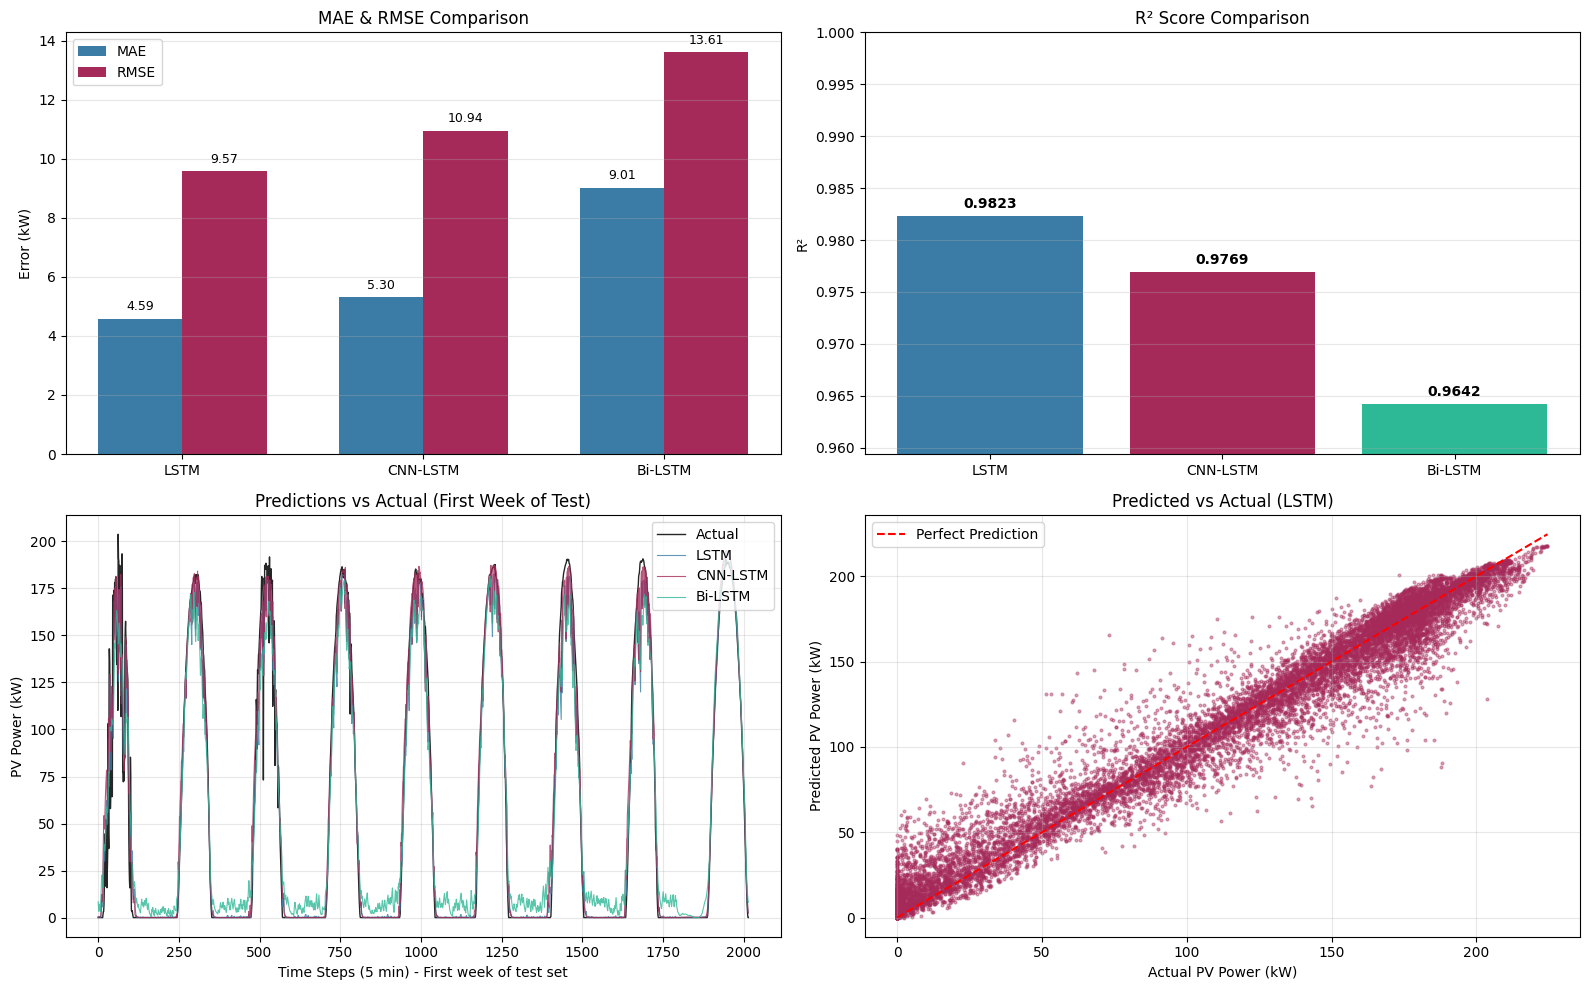

In [17]:
# ============================================================
# CELL: PV 5-MIN GPU - ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (TABLE + 4-PANEL)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

# === Inverse scale πραγματικών και προβλέψεων ===
y_true_kw = scaler_y.inverse_transform(y_te_5.reshape(-1, 1)).flatten()

preds_scaled = {
    'LSTM':     pred_lstm_5,
    'CNN-LSTM': pred_cnnlstm_5,
    'Bi-LSTM':  pred_bilstm_5,
}
preds_kw = {}
for name, p in preds_scaled.items():
    preds_kw[name] = scaler_y.inverse_transform(p.reshape(-1, 1)).flatten()
    preds_kw[name] = np.clip(preds_kw[name], 0, None)  # δεν έχουμε αρνητική παραγωγή

# === Υπολογισμός μετρικών ===
metrics = {}
for name, p_kw in preds_kw.items():
    mae  = mean_absolute_error(y_true_kw, p_kw)
    rmse = np.sqrt(mean_squared_error(y_true_kw, p_kw))
    r2   = r2_score(y_true_kw, p_kw)
    nmae = mae / (y_true_kw.max() - y_true_kw.min()) * 100
    metrics[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'nMAE%': nmae}

# === Print table ===
print("="*70)
print(" PV 5-MIN AHEAD - ΣΥΓΚΡΙΣΗ ΜΟΝΤΕΛΩΝ (GPU - DL)")
print("="*70)
print(f"{'Model':<12} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>9}")
print("-"*70)
for name, m in metrics.items():
    print(f"{name:<12} {m['MAE']:>10.3f} {m['RMSE']:>11.3f} {m['R2']:>8.4f} {m['nMAE%']:>8.2f}%")
print("-"*70)
best_name = min(metrics.items(), key=lambda x: x[1]['MAE'])[0]
print(f">>> Best: {best_name} (MAE={metrics[best_name]['MAE']:.3f} kW)")
print("="*70)

# === 4-PANEL PLOT ===
model_names = list(preds_kw.keys())
mae_vals  = [metrics[m]['MAE']  for m in model_names]
rmse_vals = [metrics[m]['RMSE'] for m in model_names]
r2_vals   = [metrics[m]['R2']   for m in model_names]
colors    = ['#3a7ca5', '#a52a5a', '#2db896']

fig = plt.figure(figsize=(16, 10))

# Top-left: MAE & RMSE bars
ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(model_names))
w = 0.35
bars_mae  = ax1.bar(x - w/2, mae_vals,  w, label='MAE',  color='#3a7ca5')
bars_rmse = ax1.bar(x + w/2, rmse_vals, w, label='RMSE', color='#a52a5a')
ax1.set_xticks(x); ax1.set_xticklabels(model_names)
ax1.set_ylabel('Error (kW)'); ax1.set_title('MAE & RMSE Comparison')
ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3, axis='y')
for b in list(bars_mae) + list(bars_rmse):
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + 0.2, f'{h:.2f}', ha='center', va='bottom', fontsize=9)

# Top-right: R² bars
ax2 = plt.subplot(2, 2, 2)
bars_r2 = ax2.bar(model_names, r2_vals, color=colors)
ax2.set_ylabel('R²'); ax2.set_title('R² Score Comparison')
ax2.set_ylim(min(r2_vals)*0.995, 1.0); ax2.grid(True, alpha=0.3, axis='y')
for b in bars_r2:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2, h + 0.0005, f'{h:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Bottom-left: First week predictions vs actual (2016 steps = 7 ημέρες × 288 5min)
ax3 = plt.subplot(2, 2, 3)
n_week = min(2016, len(y_true_kw))
ax3.plot(y_true_kw[:n_week], 'k-', lw=1, label='Actual', alpha=0.85)
for m, c in zip(model_names, colors):
    ax3.plot(preds_kw[m][:n_week], '-', lw=0.8, color=c, label=m, alpha=0.8)
ax3.set_xlabel('Time Steps (5 min) - First week of test set')
ax3.set_ylabel('PV Power (kW)')
ax3.set_title('Predictions vs Actual (First Week of Test)')
ax3.legend(loc='upper right'); ax3.grid(True, alpha=0.3)

# Bottom-right: Scatter for best model
ax4 = plt.subplot(2, 2, 4)
best_pred = preds_kw[best_name]
ax4.scatter(y_true_kw, best_pred, s=4, alpha=0.4, c='#a52a5a')
lims = [0, max(y_true_kw.max(), best_pred.max())]
ax4.plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')
ax4.set_xlabel('Actual PV Power (kW)')
ax4.set_ylabel('Predicted PV Power (kW)')
ax4.set_title(f'Predicted vs Actual ({best_name})')
ax4.legend(loc='upper left'); ax4.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'pv_5min_gpu_comparison.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()

In [18]:
# ============================================================
# CELL 12: ΩΡΙΑΙΑ ANALYSIS + DUAL-INPUT SEQUENCES
# ============================================================
from tensorflow.keras.layers import (RepeatVector, TimeDistributed,
                                      Concatenate, Bidirectional)
from tensorflow.keras.models import Model

# === Resample σε 1-hour ===
df_h = df.resample('1h').mean()
df_h = df_h.dropna()

# Recompute cyclical features σε ωριαίο επίπεδο
df_h['hour_sin']  = np.sin(2*np.pi*df_h.index.hour / 24)
df_h['hour_cos']  = np.cos(2*np.pi*df_h.index.hour / 24)
df_h['month_sin'] = np.sin(2*np.pi*df_h.index.month / 12)
df_h['month_cos'] = np.cos(2*np.pi*df_h.index.month / 12)

print(f"Hourly dataset: {df_h.shape}")
print(f"Range: {df_h.index.min()} -> {df_h.index.max()}")

# === Features ===
# Future weather (γνωστά εκ των προτέρων από NWP/perfect forecast)
WEATHER_FEAT = [
    'Global_Horizontal_Radiation',
    'Diffuse_Horizontal_Radiation',
    'Weather_Temperature_Celsius',
    'Weather_Relative_Humidity',
    'hour_sin', 'hour_cos',
    'month_sin', 'month_cos'
]
# Past full features (weather + PV history)
PAST_FEAT = WEATHER_FEAT + ['PV_Power']

# === Train/test split (80/20 σε ωριαίο επίπεδο) ===
split = int(len(df_h) * 0.80)
train_h = df_h.iloc[:split].copy()
test_h  = df_h.iloc[split:].copy()
print(f"\nTrain: {len(train_h)} hours  ({train_h.index.min()} -> {train_h.index.max()})")
print(f"Test:  {len(test_h)} hours  ({test_h.index.min()} -> {test_h.index.max()})")

# === Scalers ===
scaler_past = MinMaxScaler()
scaler_fut  = MinMaxScaler()
scaler_y    = MinMaxScaler()

X_tr_past = scaler_past.fit_transform(train_h[PAST_FEAT])
X_tr_fut  = scaler_fut.fit_transform(train_h[WEATHER_FEAT])
y_tr_raw  = scaler_y.fit_transform(train_h[['PV_Power']]).flatten()

X_te_past = scaler_past.transform(test_h[PAST_FEAT])
X_te_fut  = scaler_fut.transform(test_h[WEATHER_FEAT])
y_te_raw  = scaler_y.transform(test_h[['PV_Power']]).flatten()

target_range = train_h['PV_Power'].max() - train_h['PV_Power'].min()
print(f"\nTarget range (hourly): {target_range:.2f} kW")

# === Δημιουργία Dual Sequences ===
LOOKBACK = 24    # past 24 hours
HORIZON  = 24    # forecast next 24 hours

def create_dual_seq(X_past, X_fut, y, lookback, horizon, stride):
    X1, X2, ys = [], [], []
    for i in range(0, len(X_past) - lookback - horizon + 1, stride):
        X1.append(X_past[i : i+lookback])
        X2.append(X_fut[i+lookback : i+lookback+horizon])
        ys.append(y[i+lookback : i+lookback+horizon])
    return np.array(X1), np.array(X2), np.array(ys)

# Train: stride=1 (κάθε ώρα -> πολλά samples)
X1_tr, X2_tr, y_tr = create_dual_seq(X_tr_past, X_tr_fut, y_tr_raw, LOOKBACK, HORIZON, stride=1)
# Test: stride=24 (non-overlapping ημέρες - fair evaluation)
X1_te, X2_te, y_te = create_dual_seq(X_te_past, X_te_fut, y_te_raw, LOOKBACK, HORIZON, stride=24)

print(f"\nTrain: past={X1_tr.shape}  future_weather={X2_tr.shape}  y={y_tr.shape}")
print(f"Test:  past={X1_te.shape}  future_weather={X2_te.shape}  y={y_te.shape}")

# Reshape y για TimeDistributed output
y_tr_3d = y_tr.reshape(y_tr.shape[0], y_tr.shape[1], 1)

# Callbacks
cb_da = [
    EarlyStopping(monitor='val_loss', patience=20, min_delta=1e-5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                      min_lr=1e-6, verbose=1)
]
print("\nSetup OK")

Hourly dataset: (13206, 9)
Range: 2024-03-01 00:00:00 -> 2025-09-04 12:00:00

Train: 10564 hours  (2024-03-01 00:00:00 -> 2025-05-17 10:00:00)
Test:  2642 hours  (2025-05-17 11:00:00 -> 2025-09-04 12:00:00)

Target range (hourly): 210.09 kW

Train: past=(10517, 24, 9)  future_weather=(10517, 24, 8)  y=(10517, 24)
Test:  past=(109, 24, 9)  future_weather=(109, 24, 8)  y=(109, 24)

Setup OK


In [19]:
# ============================================================
# CELL 13: ENCODER-DECODER LSTM (Day-Ahead)
# Past 24h (PV+weather) -> encode -> combine with future weather -> decode 24h PV
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

# --- Inputs ---
past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# --- Encoder ---
enc = LSTM(64, return_sequences=False)(past_in)
enc = Dropout(0.15)(enc)

# --- Bridge: επαναλαμβάνουμε encoded state 24 φορές ---
enc_rep = RepeatVector(HORIZON)(enc)

# --- Combine encoded past με future weather ---
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# --- Decoder ---
dec = LSTM(64, return_sequences=True)(dec_in)
dec = Dropout(0.15)(dec)
dec = LSTM(32, return_sequences=True)(dec)

# --- Output ---
out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_lstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_lstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                      loss='mse', metrics=['mae'])
model_lstm_da.summary()

t0 = time.time()
h_lstm_da = model_lstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                              validation_split=0.1,
                              epochs=80, batch_size=64,
                              callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_lstm_da = model_lstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_lstm_da = np.clip(pred_lstm_da, 0, 1)   # δεν επιτρέπεται αρνητικό PV
res_lstm_da = evaluate(y_te.flatten(), pred_lstm_da.flatten(), scaler_y, target_range)
print(f"\nLSTM Day-Ahead: MAE={res_lstm_da['MAE']:.3f}  RMSE={res_lstm_da['RMSE']:.3f}  R²={res_lstm_da['R2']:.4f}  nMAE={res_lstm_da['nMAE%']:.2f}%")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ past (InputLayer)   │ (None, 24, 9)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     18,944 │ past[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 24, 64)    │          0 │ dropout[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ future_weather      │ (None, 24, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 24, 72)    │          0 │ repeat_vector[0]… │
│ (Concatenate)       │                   │            │ future_weather[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 24, 64)    │     35,072 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 24, 32)    │     12,416 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 16)    │        528 │ lstm_2[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 24, 1)     │         17 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 66,977 (261.63 KB)

 Trainable params: 66,977 (261.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - loss: 0.0370 - mae: 0.1297 - val_loss: 0.0157 - val_mae: 0.0813 - learning_rate: 5.0000e-04
Epoch 2/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - loss: 0.0114 - mae: 0.0657 - val_loss: 0.0104 - val_mae: 0.0668 - learning_rate: 5.0000e-04
Epoch 3/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0083 - mae: 0.0551 - val_loss: 0.0115 - val_mae: 0.0696 - learning_rate: 5.0000e-04
Epoch 4/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0067 - mae: 0.0485 - val_loss: 0.0075 - val_mae: 0.0564 - learning_rate: 5.0000e-04
Epoch 5/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0056 - mae: 0.0442 - val_loss: 0.0077 - val_mae: 0.0564 - learning_rate: 5.0000e-04
Epoch 6/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0049 - mae: 0.0411 - val_loss: 0.0073 - val_mae: 0.0536 - learning_rate: 5.0000e-04
Epoch 7/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0044 - mae: 0.0384 - val_loss: 0.0078 - val_mae: 0.05

In [20]:
# ============================================================
# CELL 14: CNN-LSTM ENCODER-DECODER (διορθωμένο - απλούστερο CNN front)
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# --- Απλό CNN front (1 layer, μικρός kernel) ---
x = Conv1D(32, kernel_size=2, activation='relu', padding='same')(past_in)
x = Dropout(0.1)(x)

# --- LSTM Encoder ---
enc = LSTM(64, return_sequences=False)(x)
enc = Dropout(0.15)(enc)

# --- Bridge ---
enc_rep = RepeatVector(HORIZON)(enc)
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# --- LSTM Decoder ---
dec = LSTM(64, return_sequences=True)(dec_in)
dec = Dropout(0.15)(dec)
dec = LSTM(32, return_sequences=True)(dec)

out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_cnnlstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_cnnlstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                         loss='mse', metrics=['mae'])

t0 = time.time()
h_cnnlstm_da = model_cnnlstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                                    validation_split=0.1,
                                    epochs=80, batch_size=64,
                                    callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_cnnlstm_da = model_cnnlstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_cnnlstm_da = np.clip(pred_cnnlstm_da, 0, 1)
res_cnnlstm_da = evaluate(y_te.flatten(), pred_cnnlstm_da.flatten(), scaler_y, target_range)
print(f"\nCNN-LSTM Day-Ahead: MAE={res_cnnlstm_da['MAE']:.3f}  RMSE={res_cnnlstm_da['RMSE']:.3f}  R²={res_cnnlstm_da['R2']:.4f}  nMAE={res_cnnlstm_da['nMAE%']:.2f}%")

Epoch 1/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 0.0403 - mae: 0.1322 - val_loss: 0.0202 - val_mae: 0.0892 - learning_rate: 5.0000e-04
Epoch 2/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0134 - mae: 0.0697 - val_loss: 0.0096 - val_mae: 0.0590 - learning_rate: 5.0000e-04
Epoch 3/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0092 - mae: 0.0569 - val_loss: 0.0073 - val_mae: 0.0531 - learning_rate: 5.0000e-04
Epoch 4/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0070 - mae: 0.0492 - val_loss: 0.0072 - val_mae: 0.0537 - learning_rate: 5.0000e-04
Epoch 5/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0058 - mae: 0.0440 - val_loss: 0.0066 - val_mae: 0.0505 - learning_rate: 5.0000e-04
Epoch 6/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0049 - mae: 0.0402 - val_loss: 0.0057 - val_mae: 0.0484 - learning_rate: 5.0000e-04
Epoch 7/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0045 - mae: 0.0382
Epoch 7: ReduceLROnPlateau reducing 


CNN-LSTM Day-Ahead: MAE=20.445  RMSE=39.988  R²=0.6848  nMAE=9.73%


In [21]:
# ============================================================
# CELL 15: Bi-LSTM ENCODER-DECODER (Day-Ahead)
# ============================================================
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

past_in = Input(shape=(LOOKBACK, X1_tr.shape[2]), name='past')
fut_in  = Input(shape=(HORIZON,  X2_tr.shape[2]), name='future_weather')

# --- Bidirectional Encoder ---
enc = Bidirectional(LSTM(32, return_sequences=False))(past_in)
enc = Dropout(0.15)(enc)

# --- Bridge ---
enc_rep = RepeatVector(HORIZON)(enc)
dec_in = Concatenate(axis=-1)([enc_rep, fut_in])

# --- Bidirectional Decoder ---
dec = Bidirectional(LSTM(32, return_sequences=True))(dec_in)
dec = Dropout(0.15)(dec)
dec = Bidirectional(LSTM(16, return_sequences=True))(dec)

out = TimeDistributed(Dense(16, activation='relu'))(dec)
out = TimeDistributed(Dense(1))(out)

model_bilstm_da = Model(inputs=[past_in, fut_in], outputs=out)
model_bilstm_da.compile(optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
                        loss='mse', metrics=['mae'])

t0 = time.time()
h_bilstm_da = model_bilstm_da.fit([X1_tr, X2_tr], y_tr_3d,
                                  validation_split=0.1,
                                  epochs=80, batch_size=64,
                                  callbacks=cb_da, verbose=1)
print(f"\nΧρόνος: {(time.time()-t0)/60:.1f} min")

pred_bilstm_da = model_bilstm_da.predict([X1_te, X2_te], verbose=0).squeeze(-1)
pred_bilstm_da = np.clip(pred_bilstm_da, 0, 1)
res_bilstm_da = evaluate(y_te.flatten(), pred_bilstm_da.flatten(), scaler_y, target_range)
print(f"\nBi-LSTM Day-Ahead: MAE={res_bilstm_da['MAE']:.3f}  RMSE={res_bilstm_da['RMSE']:.3f}  R²={res_bilstm_da['R2']:.4f}  nMAE={res_bilstm_da['nMAE%']:.2f}%")

Epoch 1/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - loss: 0.0408 - mae: 0.1422 - val_loss: 0.0073 - val_mae: 0.0653 - learning_rate: 5.0000e-04
Epoch 2/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0093 - mae: 0.0647 - val_loss: 0.0049 - val_mae: 0.0486 - learning_rate: 5.0000e-04
Epoch 3/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0070 - mae: 0.0533 - val_loss: 0.0053 - val_mae: 0.0502 - learning_rate: 5.0000e-04
Epoch 4/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0061 - mae: 0.0482 - val_loss: 0.0050 - val_mae: 0.0486 - learning_rate: 5.0000e-04
Epoch 5/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0055 - mae: 0.0446 - val_loss: 0.0047 - val_mae: 0.0477 - learning_rate: 5.0000e-04
Epoch 6/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0050 - mae: 0.0420 - val_loss: 0.0041 - val_mae: 0.0439 - learning_rate: 5.0000e-04
Epoch 7/80
148/148 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0047 - mae: 0.0400
Epoch 7: ReduceLROnPlateau reducing

 PV DAY-AHEAD FORECAST (ΩΡΙΑΙΑ, 24-step, με perfect weather forecast)
Model          MAE (kW)   RMSE (kW)       R²    nMAE %
------------------------------------------------------------------------------
LSTM              3.688       6.603   0.9914     1.76%
CNN-LSTM         20.445      39.988   0.6848     9.73%
Bi-LSTM          15.448      22.366   0.9014     7.35%

Επιλεγμένες ηλιόλουστες ημέρες:
  Sample #0: ξεκινάει 2025-05-18 11:00, max PV = 189.8 kW
  Sample #1: ξεκινάει 2025-05-19 11:00, max PV = 189.8 kW
  Sample #2: ξεκινάει 2025-05-20 11:00, max PV = 188.5 kW

✓ Saved: /content/drive/MyDrive/Final_RUn/pv_da_gpu_3days.png


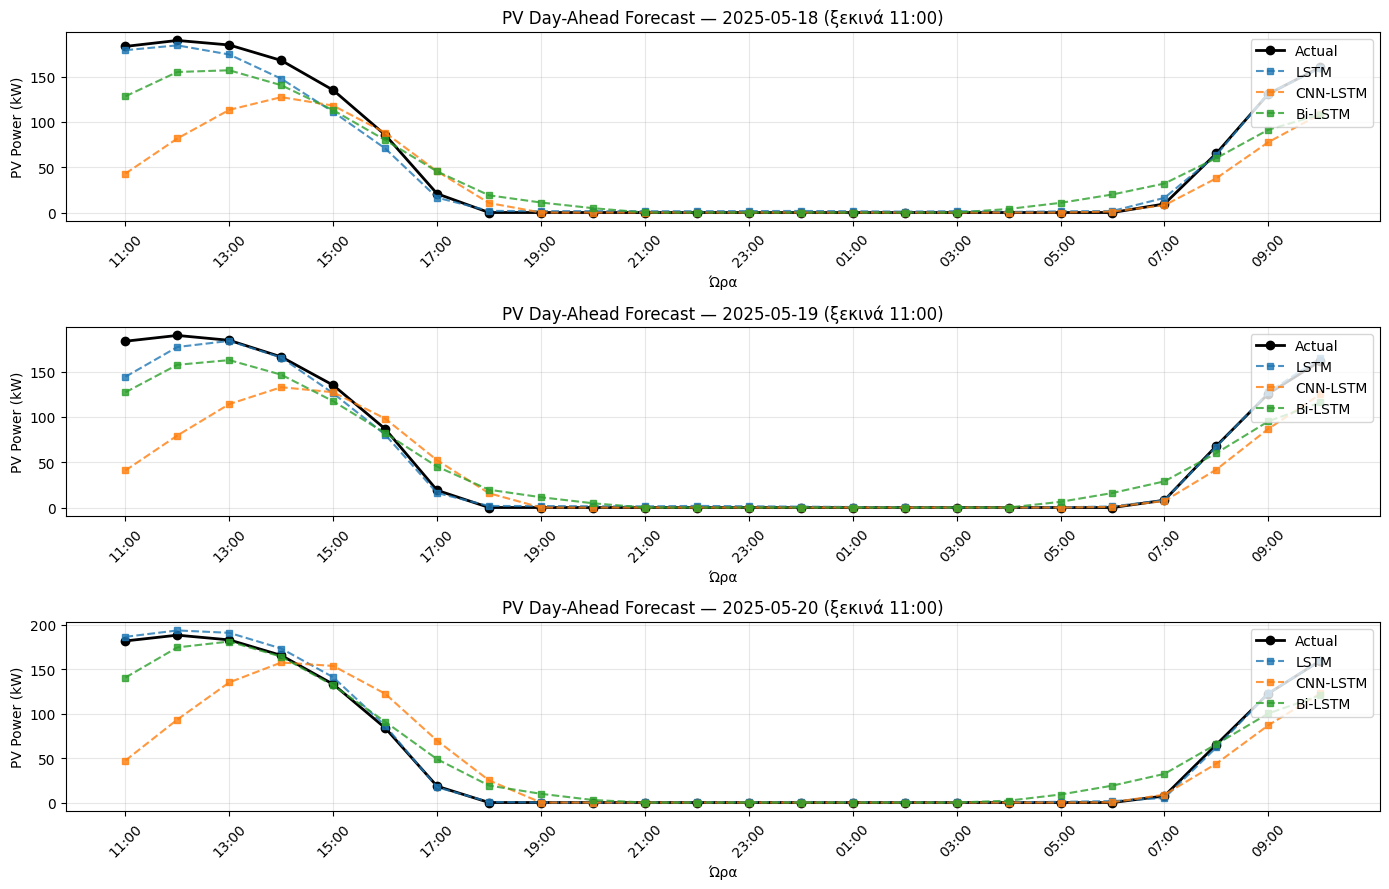

In [25]:
# ============================================================
# CELL 16: COMPARISON DAY-AHEAD - 3 ηλιόλουστες ημέρες με σωστές ώρες
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

SAVE_DIR = '/content/drive/MyDrive/Final_RUn/'

results_da = {
    'LSTM':     (res_lstm_da,    pred_lstm_da),
    'CNN-LSTM': (res_cnnlstm_da, pred_cnnlstm_da),
    'Bi-LSTM':  (res_bilstm_da,  pred_bilstm_da),
}

print("="*78)
print(" PV DAY-AHEAD FORECAST (ΩΡΙΑΙΑ, 24-step, με perfect weather forecast)")
print("="*78)
print(f"{'Model':<12} {'MAE (kW)':>10} {'RMSE (kW)':>11} {'R²':>8} {'nMAE %':>9}")
print("-"*78)
for name, (r, _) in results_da.items():
    print(f"{name:<12} {r['MAE']:>10.3f} {r['RMSE']:>11.3f} {r['R2']:>8.4f} {r['nMAE%']:>8.2f}%")

# === Inverse scale όλων των actuals για να βρούμε ηλιόλουστες ημέρες ===
n_days_total = y_te.shape[0]
all_actuals_kw = np.zeros((n_days_total, 24))
for i in range(n_days_total):
    all_actuals_kw[i] = scaler_y.inverse_transform(y_te[i].reshape(-1, 1)).flatten()

# Βρες τα timestamps της κάθε ημέρας: ξεκινά από test_h.index[LOOKBACK + i*24]
# αλλά πρέπει να γίνει χρονική ευθυγράμμιση γιατί τα δείγματα ξεκινούν στις 11:00
day_starts_idx = [LOOKBACK + i*24 for i in range(n_days_total)]
day_start_timestamps = [test_h.index[idx] for idx in day_starts_idx]

# Επέλεξε 3 ηλιόλουστες ημέρες (max actual > 150 kW)
SUNNY_THRESHOLD = 150
sunny_idx = []
for i in range(n_days_total):
    if all_actuals_kw[i].max() > SUNNY_THRESHOLD:
        sunny_idx.append(i)
    if len(sunny_idx) >= 3:
        break

print(f"\nΕπιλεγμένες ηλιόλουστες ημέρες:")
for i in sunny_idx:
    ts = day_start_timestamps[i]
    print(f"  Sample #{i}: ξεκινάει {ts.strftime('%Y-%m-%d %H:%M')}, max PV = {all_actuals_kw[i].max():.1f} kW")

# === Plot ===
fig, axes = plt.subplots(len(sunny_idx), 1, figsize=(14, 3*len(sunny_idx)))
if len(sunny_idx) == 1: axes = [axes]

for plot_pos, day_idx in enumerate(sunny_idx):
    ax = axes[plot_pos]
    start_ts = day_start_timestamps[day_idx]

    # Δημιουργία array των ωρών (HH:MM) για το x-axis
    timestamps_24h = [start_ts + pd.Timedelta(hours=h) for h in range(24)]
    hour_labels = [ts.strftime('%H:%M') for ts in timestamps_24h]

    actual = all_actuals_kw[day_idx]
    ax.plot(range(24), actual, 'k-', label='Actual', lw=2, marker='o')

    for name, (_, preds) in results_da.items():
        pred = scaler_y.inverse_transform(preds[day_idx].reshape(-1, 1)).flatten()
        pred = np.clip(pred, 0, None)
        ax.plot(range(24), pred, '--', label=name, alpha=0.8, marker='s', markersize=4)

    date_str = start_ts.strftime('%Y-%m-%d')
    ax.set_title(f'PV Day-Ahead Forecast — {date_str} (ξεκινά {start_ts.strftime("%H:%M")})')
    ax.set_xlabel('Ώρα')
    ax.set_ylabel('PV Power (kW)')

    # Δείχνουμε κάθε 2η ώρα στο x-axis
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([hour_labels[h] for h in range(0, 24, 2)], rotation=45)

    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = SAVE_DIR + 'pv_da_gpu_3days.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f"\n✓ Saved: {out_path}")
plt.show()